In [18]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=1000)
print(train_data[0:5])
print(max([max(sequence) for sequence in train_data]))
maximum=[max(sequence) for sequence in train_data]
print(maximum)

[list([1, 14, 22, 16, 43, 530, 973, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 2, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32])
 list([1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 715, 8, 118, 2, 14, 394, 20, 13, 119, 954, 189, 102, 5, 207,

In [19]:
# Revert to Text

word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]])

In [20]:
decoded_review[:100]

'? this film was just brilliant casting ? ? story direction ? really ? the part they played and you c'

In [22]:
lengths = [len(seq) for seq in train_data]
longest_idx = lengths.index(max(lengths))

print(f"Longest review index: {longest_idx}")
print(f"Number of words in it: {max(lengths)}")

# 2. Get the word index mapping
word_index = imdb.get_word_index()
# Reverse mapping: original index -> word
# Note: IMDB reserves indices 0,1,2 for padding, start, unknown
reverse_word_index = {value: key for key, value in word_index.items()}

# 3. Decode the longest review
# Indices in train_data are offset by 3 compared to word_index
decoded_longest = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[longest_idx]]
)

print("\nDecoded longest review:\n", decoded_longest)

Longest review index: 17934
Number of words in it: 2494

Decoded longest review:
 ? ? 1 ? team ? ? ? ? and ? ? ? ? ? and ? ? ? ? and ? ? started things off with a ? team ? ? against ? ? and ? ? ? to the ? of the ? both ? have to go through ? in order to get the ? ? and ? ? up early on by taking turns ? first ? and then ? ? a ? ? by ? to ? took the ? out of the ? brother ? tried to help his brother but the ? ? him while ? and ? ? up on him in the ? with ? ? away on ? ? set up a ? ? ? ? into the ? and ? over the top ? ? ? on the ? after ? and taking care of ? ? ? a ? into the ? and ? the ? set it up the ? then set up for a ? ? from the middle ? which would have put ? through the ? but ? ? the ? over right before his brother came ? down ? and ? ? another ? in the ? and tried to ? ? ? through it but ? ? in and ? his brother ? ? fire and ? both ? into back body ? ? ? ? and ? ? on the ? from off the top ? ? ? ? at ? for ? to ? into the ? ? ? after ? ? ? in the ? but the ? ? even after ? ? ou

In [28]:
# Encoding the integer sequences via multi-hot encoding

import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [45]:
import keras
from keras import layers
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_split=0.2)

history_dict = history.history
history_dict.keys()

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7709 - loss: 0.5217 - val_accuracy: 0.8444 - val_loss: 0.3868
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8571 - loss: 0.3475 - val_accuracy: 0.8576 - val_loss: 0.3412
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8692 - loss: 0.3171 - val_accuracy: 0.8626 - val_loss: 0.3345
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8733 - loss: 0.3087 - val_accuracy: 0.8628 - val_loss: 0.3382
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8759 - loss: 0.3026 - val_accuracy: 0.8596 - val_loss: 0.3386
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8720 - loss: 0.3065 - val_accuracy: 0.8646 - val_loss: 0.3330
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8742 - loss: 0.3025 - val_accuracy: 0.8582 - val_loss: 0.3368
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8801 - loss: 0.2937 - val_accuracy: 0.8634 - val_loss

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

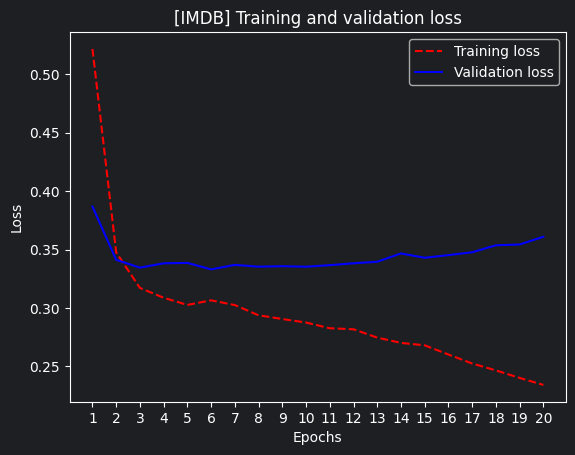

In [47]:
# Plotting the training and validation loss

import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss") #1
plt.plot(epochs, val_loss_values, "b", label="Validation loss") #2
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.savefig("imdb_loss_plot.png", dpi=300)

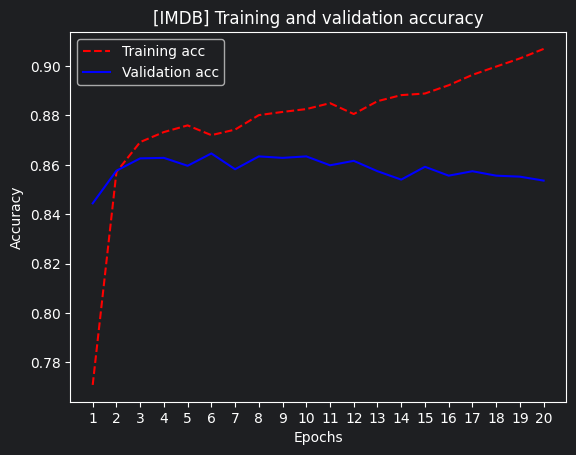

In [50]:
# Plotting the training and validation accuracy

plt.clf() # clear
acc=history_dict["accuracy"]
val_acc=history_dict["val_accuracy"]
plt.plot(epochs,acc,"r--",label="Training acc")
plt.plot(epochs,val_acc,"b",label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.savefig("imdb_accuracy_plot.png",dpi=700)

In [52]:
# Avoid overfitting (seen before after 4th epoch)

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)
model.predict(x_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7790 - loss: 0.5240
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8604 - loss: 0.3464
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8702 - loss: 0.3154
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8732 - loss: 0.3068
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8598 - loss: 0.3286
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


array([[0.3391871 ],
       [0.99536943],
       [0.54692686],
       ...,
       [0.0920751 ],
       [0.06990338],
       [0.42181316]], shape=(25000, 1), dtype=float32)

In [58]:
# Sandbox

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.fit(x_train, y_train, epochs=4, batch_size=32)
results = model.evaluate(x_test, y_test)
model.predict(x_test)

Epoch 1/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8408 - loss: 0.3839
Epoch 2/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8652 - loss: 0.3222
Epoch 3/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8666 - loss: 0.3150
Epoch 4/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8724 - loss: 0.3070
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8506 - loss: 0.3442
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.16385643],
       [0.9983215 ],
       [0.31999353],
       ...,
       [0.06954072],
       [0.03720853],
       [0.3233677 ]], shape=(25000, 1), dtype=float32)